# Multi-Layer Perceptrons — MNIST Lab

**Dataset:** MNIST Handwritten Digits (built into Keras)

---

### Learning Objectives
By the end of this lab you will be able to:
1. Build and train a multi-layer perceptron (MLP) using the Keras functional API
2. Understand the role of each layer type: Input, Dense, Dropout
3. Compare the effect of different activation functions on classification performance
4. Implement Early Stopping to prevent overfitting
5. Plot and interpret training vs. validation learning curves
6. Experiment with Dropout regularization

> **Recall from lecture:** A single perceptron can only model linearly separable data. By stacking perceptrons into layers — each using a *non-linear* activation function — we gain the ability to model arbitrarily complex patterns. This is the core idea behind a neural network.

---
## Part 0 — Environment Setup

### What we're installing and why

| Package | Purpose |
|---|---|
| `tensorflow` | The engine that runs our neural network computations. Keras is now bundled inside TensorFlow as `tf.keras`. |


> **Note on training time:** MNIST is intentionally small (~60k images). Even so, training a neural network involves millions of floating-point operations per epoch. On a standard laptop CPU, expect **1–3 minutes** per run. On Google Colab with a free GPU this drops to under 30 seconds. If training feels slow, reduce `epochs` or `batch_size`.

Run the cell below **once** at the start of your session.

In [1]:
# Install dependencies — only needs to run once per environment
!pip install tensorflow --quiet


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Suppress TensorFlow info/warning logs for cleaner output
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow version: {tf.__version__}")
print("✅ All imports successful!")

TensorFlow version: 2.21.0
✅ All imports successful!


---
## Part 1 — The MNIST Dataset

MNIST is the "hello world" of computer vision — 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels. Our goal is to build a neural network that correctly identifies which digit is in each image.

### Why 784 input nodes?
Each image is 28×28 = **784 pixels**. We flatten the 2D grid into a 1D vector of 784 numbers, where each number represents the brightness of one pixel (0 = black, 255 = white). Each pixel becomes one input feature — so our input layer has 784 nodes.

In [3]:
# Load the MNIST dataset — already split into train/test by Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training images : {x_train.shape}  — {len(x_train):,} images of shape 28x28")
print(f"Training labels : {y_train.shape}  — integers 0–9")
print(f"Test images     : {x_test.shape}")
print(f"Test labels     : {y_test.shape}")
print(f"Pixel value range (raw): {x_train.min()} – {x_train.max()}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images : (60000, 28, 28)  — 60,000 images of shape 28x28
Training labels : (60000,)  — integers 0–9
Test images     : (10000, 28, 28)
Test labels     : (10000,)
Pixel value range (raw): 0 – 255


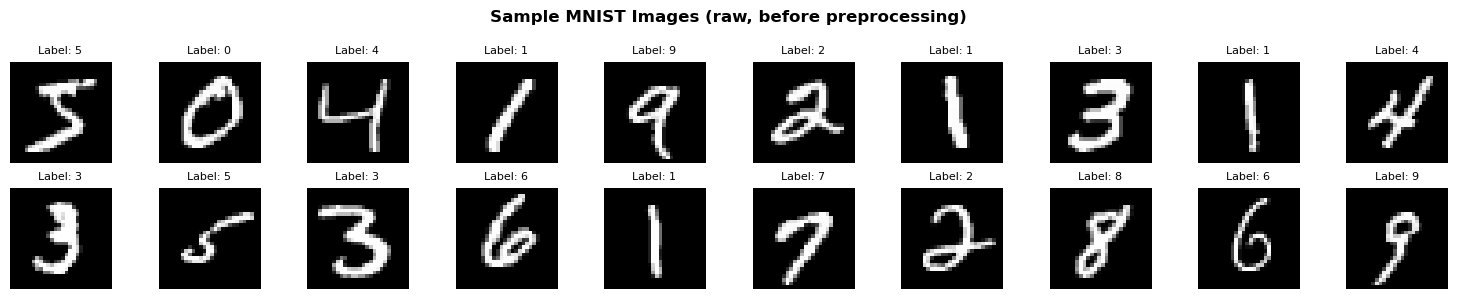

In [4]:
# Visualize a sample of digits before preprocessing
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Sample MNIST Images (raw, before preprocessing)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Preprocessing: Flatten + Normalize

Two things must happen before feeding images into our MLP:

1. **Flatten** — reshape from `(28, 28)` → `(784,)`. Our Dense layers expect a 1D input vector, not a 2D grid.
2. **Normalize** — divide pixel values by 255 so they fall in `[0, 1]` instead of `[0, 255]`. This is the same intuition as `StandardScaler` from our earlier work: features on wildly different scales make gradient descent unstable. Neural networks are especially sensitive to this.

In [5]:
# Flatten: (60000, 28, 28) → (60000, 784)
# Normalize: pixel values from [0, 255] → [0.0, 1.0]
x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test  = x_test.reshape(10000, 784).astype("float32") / 255

print(f"After preprocessing:")
print(f"  x_train shape : {x_train.shape}")
print(f"  Pixel range   : {x_train.min():.1f} – {x_train.max():.1f}")

After preprocessing:
  x_train shape : (60000, 784)
  Pixel range   : 0.0 – 1.0


---
## Part 2 — Understanding the Layer Types

Before we build anything, let's get clear on what each layer actually does.

---

### 🔵 Input Layer — `keras.Input(shape=(784,))`
This is not a computational layer — it's a **declaration**. It tells Keras the shape of the data that will enter the network. For MNIST, each sample is a vector of 784 numbers, so `shape=(784,)`. Think of it as the front door of the network.

---

### 🟢 Dense Layer — `layers.Dense(units, activation=...)`
This is the core building block of an MLP — the "fully connected" layer. Every node in this layer is connected to **every node** in the previous layer. The layer learns a weight for each of those connections via backpropagation.

- `units` = number of neurons in this layer
- `activation` = the non-linear function applied after the weighted sum (more on this shortly)
- In our architecture: hidden layer has 64 units, output layer has 10 units (one per digit class)

---

### 🟠 Dropout Layer — `layers.Dropout(rate)`
A **regularization** technique. During each training step, Dropout randomly "turns off" a fraction of neurons (sets their output to 0). This forces the network to not rely too heavily on any single neuron, making it more robust and reducing overfitting.

- `rate=0.3` means 30% of neurons are randomly disabled each step
- Dropout is **only active during training** — it's automatically disabled at evaluation time
- You will experiment with this in Part 5

---

### 🔴 Output Layer — `layers.Dense(10)`
The final layer produces one score per class (10 digits). No activation is applied here because we pass `from_logits=True` to our loss function, which handles the softmax conversion internally. The class with the highest score is the predicted digit.

---

### A note on Conv2D and MaxPooling2D
The Keras MNIST example in lecture references convolutional layers. Here's the distinction:

| Layer | Used In | What it does |
|---|---|---|
| `Dense` | MLP (this lab) | Fully connected — every neuron talks to every neuron in the next layer |
| `Conv2D` | CNN | Learns spatial filters that detect edges, shapes, textures in 2D images |
| `MaxPooling2D` | CNN | Downsamples feature maps to reduce computation and add spatial invariance |

We are building an **MLP** today, so we use Dense layers only. CNNs (which use Conv2D + MaxPooling) are the next step up in architecture and are significantly more powerful for image tasks — but the MLP is the essential foundation to understand first.

---
## Part 3 — Build and Train Your First MLP

We'll use the architecture from lecture as our baseline:

```
Input (784)  →  Dense 64, ReLU  →  Dense 10 (output)
```

In [6]:
def build_model(hidden_units=64, activation='relu', dropout_rate=0.0):
    """
    Builds a simple MLP for MNIST classification.
    
    Parameters
    ----------
    hidden_units  : number of neurons in the hidden Dense layer
    activation    : activation function for the hidden layer
    dropout_rate  : fraction of neurons to drop (0.0 = no dropout)
    """
    # --- Input layer ---
    inputs = keras.Input(shape=(784,), name="input_layer")

    # --- Hidden Dense layer ---
    x = layers.Dense(hidden_units, activation=activation, name="hidden_layer")(inputs)

    # --- Dropout (optional regularization) ---
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate, name="dropout")(x)

    # --- Output layer: 10 units, one per digit class, no activation (logits) ---
    outputs = layers.Dense(10, name="output_layer")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_mlp")
    return model


# Build the baseline model
model = build_model(hidden_units=64, activation='relu')
model.summary()

Model: "mnist_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

### Reading the model summary

The **Param #** column tells you how many weights the network must learn:
- `hidden_layer`: 784 inputs × 64 neurons + 64 biases = **50,240 parameters**
- `output_layer`: 64 inputs × 10 neurons + 10 biases = **650 parameters**

That's ~50,000 numbers being updated via backpropagation every single training step. This is why neural networks need a lot of data — and why they weren't practical until modern hardware.

In [7]:
# Compile: wire up the loss function, optimizer, and metrics
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"]
)

# Train: use 20% of training data as a validation set
print("Training baseline model (ReLU, no dropout)...")
history_baseline = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

# Evaluate on held-out test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Baseline Test Accuracy: {test_acc:.4f}")

Training baseline model (ReLU, no dropout)...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8965 - loss: 0.3767 - val_accuracy: 0.9376 - val_loss: 0.2244
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9429 - loss: 0.1963 - val_accuracy: 0.9533 - val_loss: 0.1676
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9555 - loss: 0.1500 - val_accuracy: 0.9580 - val_loss: 0.1429
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9642 - loss: 0.1217 - val_accuracy: 0.9627 - val_loss: 0.1325
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9693 - loss: 0.1034 - val_accuracy: 0.9656 - val_loss: 0.1201
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9740 - loss: 0.0887 - val_accuracy: 0.9667 - val_loss: 0.1163
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9775 - loss: 0.0777 - val_accuracy: 0.9683 - val_loss: 0.1116
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accu

---
## Part 4 — Learning Curves & Early Stopping

### 📈 Learning Curves

Every call to `model.fit()` returns a `history` object containing the training and validation accuracy/loss at each epoch. Plotting these curves is one of the most important diagnostic tools in deep learning — they tell you:

- Is the model actually learning? (both curves should trend downward/upward)
- Is it overfitting? (training keeps improving but validation plateaus or gets worse)
- Did you train for too many or too few epochs?

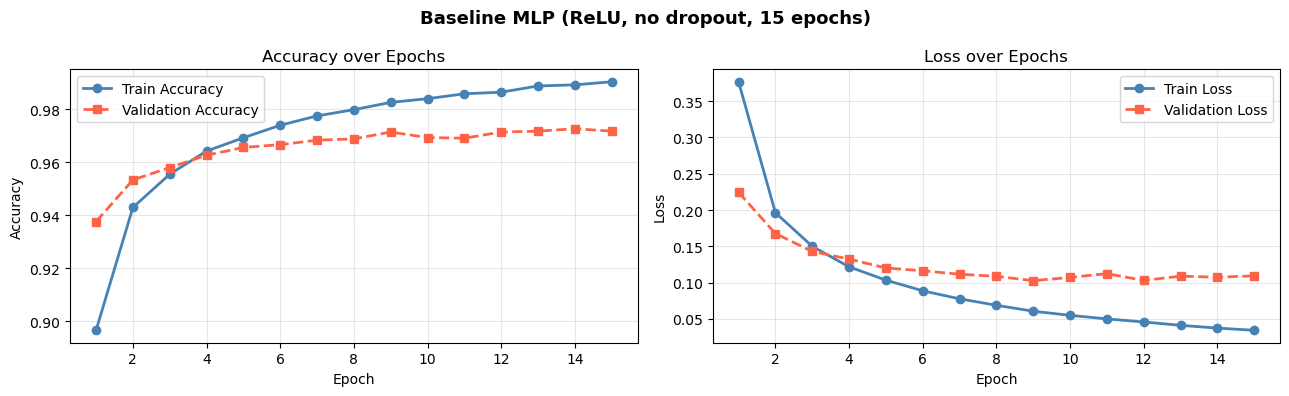

In [8]:
def plot_learning_curves(history, title="Learning Curves"):
    """Plots training vs. validation accuracy and loss side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    axes[0].plot(epochs, history.history['accuracy'],     'o-', color='steelblue',  label='Train Accuracy',      linewidth=2)
    axes[0].plot(epochs, history.history['val_accuracy'], 's--', color='tomato',    label='Validation Accuracy', linewidth=2)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy over Epochs")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs, history.history['loss'],     'o-', color='steelblue', label='Train Loss',      linewidth=2)
    axes[1].plot(epochs, history.history['val_loss'], 's--', color='tomato',   label='Validation Loss', linewidth=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].set_title("Loss over Epochs")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_learning_curves(history_baseline, title="Baseline MLP (ReLU, no dropout, 15 epochs)")

### 🛑 Early Stopping

Looking at your curves: does validation accuracy plateau or start to dip while training accuracy keeps climbing? That's overfitting — the model is memorizing the training data rather than generalizing.

**Early Stopping** solves this automatically. It monitors a metric (typically `val_loss`) and halts training as soon as the model stops improving on validation data. Key parameters:

| Parameter | What it does |
|---|---|
| `monitor` | The metric to watch — usually `'val_loss'` |
| `patience` | How many epochs of no improvement to tolerate before stopping |
| `restore_best_weights` | If `True`, rolls back to the weights from the best epoch, not the last one |

Think of `patience` like the income/happiness plateau from lecture: we stop training once the marginal gains become negligible. `restore_best_weights=True` ensures we keep the best version of the model, not the overfit one.

**TODO:** Train the model below with Early Stopping enabled. Compare when it actually stops vs. the `epochs=50` ceiling.

Training with Early Stopping (up to 50 epochs)...
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8991 - loss: 0.3725 - val_accuracy: 0.9421 - val_loss: 0.2092
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9456 - loss: 0.1893 - val_accuracy: 0.9534 - val_loss: 0.1626
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9598 - loss: 0.1396 - val_accuracy: 0.9606 - val_loss: 0.1339
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9675 - loss: 0.1116 - val_accuracy: 0.9626 - val_loss: 0.1300
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9724 - loss: 0.0946 - val_accuracy: 0.9667 - val_loss: 0.1161
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9762 - loss: 0.0815 - val_accuracy: 0.9672 - val_loss: 0.1120
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9783 - loss: 0.0727 - val_accuracy: 0.9699 - val_loss: 0.1048
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - 

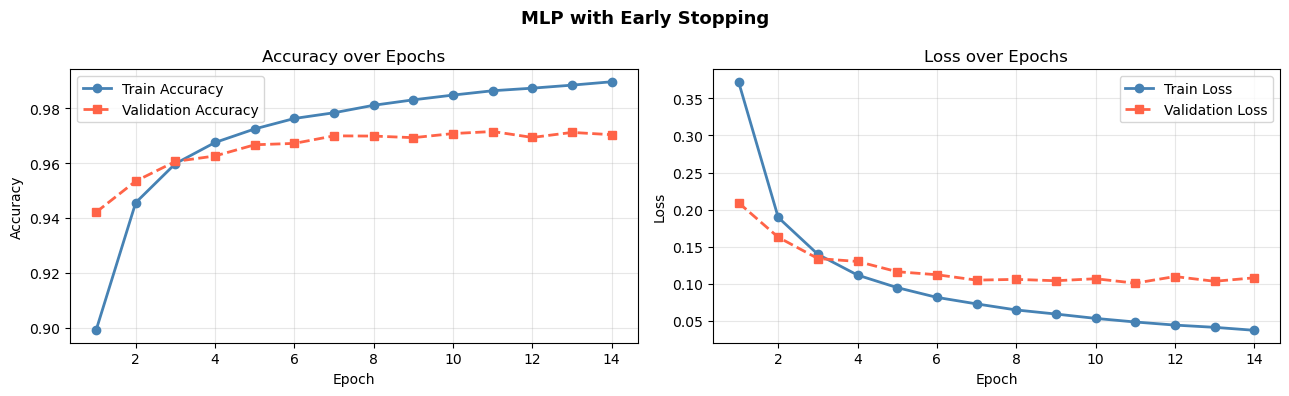

In [10]:
# ✅ TODO: fill in the patience parameter — try values between 3 and 10
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,                 # ← how many epochs of no improvement before stopping
    restore_best_weights=True,
    verbose=1
)

# Rebuild a fresh model so we start from scratch
model_es = build_model(hidden_units=64, activation='relu')
model_es.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"]
)

print("Training with Early Stopping (up to 50 epochs)...")
history_es = model_es.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,                    # ceiling — Early Stopping will kick in before this
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

test_loss_es, test_acc_es = model_es.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Early Stopping Test Accuracy: {test_acc_es:.4f}")
print(f"   Stopped at epoch: {len(history_es.history['val_loss'])}")

plot_learning_curves(history_es, title="MLP with Early Stopping")

### ✏️ Reflection 1

1. How many epochs did Early Stopping use vs. the 15-epoch baseline? Did it achieve similar or better test accuracy?
2. Looking at the baseline learning curves, at approximately which epoch does validation loss stop improving? Does that match where Early Stopping halted?

**Your answer here:**

1. Early Stopping used 14 epochs and restored model weights from the best epoch (11). It achieves similar accuracy but the 15-epoch baseline was 0.9741, compared to early stopping baseline of 0.9748. I believe Early Stopping could have performed a little better if I had selected a smaller patience level. I had set patience = 3.

2. Validation loss stops improving at epoch-2. This is the same for the  15-epoch baseline and the Early Stopping. But I may be miinterpretting the curves and will do more reading/research to ensure solid grasp of the concept. || Per in-class lab convo with TA, the validation loss stop improvement point is at the end of the graph || Upon further review, graph show that both training and validation loss decrease steadily over the epochs. This indicates effecting learning of the model. Additionally, since the gap between curves is minimal, the model isn't overfitting and should work well with unseen data.

---
## Part 5 — Comparing Activation Functions

Recall from lecture that the activation function is what gives a neural network its ability to model non-linear patterns. Without one, stacking Dense layers is mathematically equivalent to a single linear transformation — no matter how deep you go.

Here's a summary of the options:

| Activation | Formula | Strengths | Weaknesses |
|---|---|---|---|
| `relu` | `max(0, x)` | Fast, avoids vanishing gradient, standard choice | Can "die" (neurons stuck at 0) |
| `sigmoid` | `1 / (1 + e^-x)` | Smooth, probabilistic output | Vanishing gradient at extremes |
| `tanh` | `(e^x - e^-x) / (e^x + e^-x)` | Zero-centered, often better than sigmoid | Still prone to vanishing gradient |
| `softmax` | Normalizes to probabilities across classes | Great for multi-class output layer | Not ideal for hidden layers |
| `elu` | `x if x>0, α(e^x-1) otherwise` | Smoother than ReLU, handles negatives | Slightly more compute |

**TODO:** Complete the experiment loop below. Train one model per activation function and compare results.


Training with activation = 'relu'...
  → Test accuracy: 0.9742

Training with activation = 'sigmoid'...
  → Test accuracy: 0.9651

Training with activation = 'softmax'...
  → Test accuracy: 0.8395

Training with activation = 'elu'...
  → Test accuracy: 0.9691


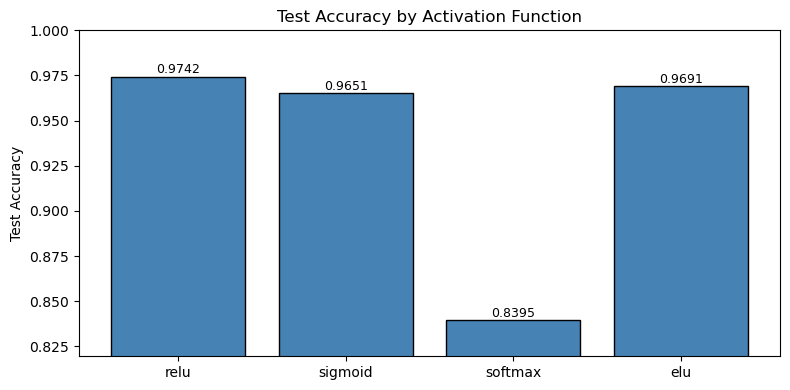

In [11]:
# ✅ TODO: add at least two more activation functions to this list
activation_functions = ['relu', 'sigmoid', 'softmax', 'elu']

results_activation = {}
histories_activation = {}

for act in activation_functions:
    print(f"\nTraining with activation = '{act}'...")
    m = build_model(hidden_units=64, activation=act)
    m.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=keras.optimizers.RMSprop(),
        metrics=["accuracy"]
    )
    hist = m.fit(
        x_train, y_train,
        batch_size=64,
        epochs=10,
        validation_split=0.2,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                          restore_best_weights=True)
        ]
    )
    _, test_acc = m.evaluate(x_test, y_test, verbose=0)
    results_activation[act] = test_acc
    histories_activation[act] = hist
    print(f"  → Test accuracy: {test_acc:.4f}")

# Bar chart comparison
plt.figure(figsize=(8, 4))
bars = plt.bar(results_activation.keys(), results_activation.values(),
               color='steelblue', edgecolor='black')
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy by Activation Function")
plt.ylim(min(results_activation.values()) - 0.02, 1.0)
for bar, val in zip(bars, results_activation.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.4f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

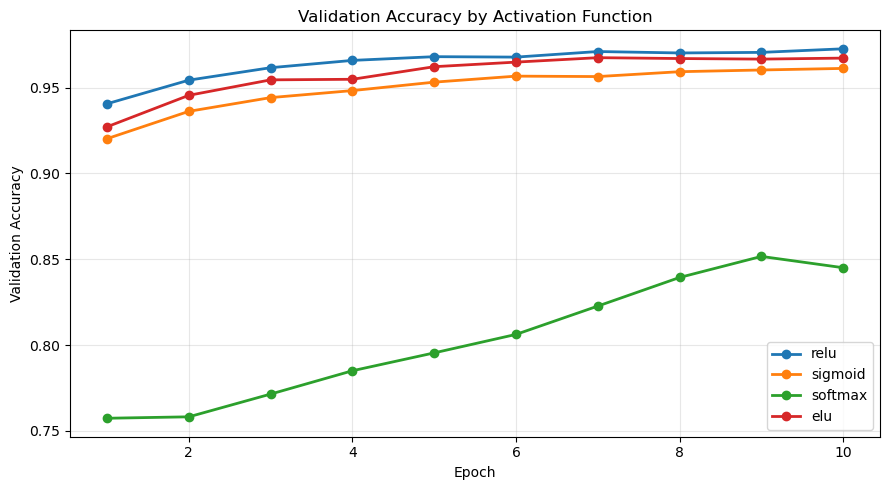

In [12]:
# Plot validation accuracy curves for all activation functions together
plt.figure(figsize=(9, 5))
for act, hist in histories_activation.items():
    epochs = range(1, len(hist.history['val_accuracy']) + 1)
    plt.plot(epochs, hist.history['val_accuracy'], marker='o', label=act, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy by Activation Function")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ✏️ Reflection 2

1. Which activation function achieved the highest test accuracy? Were you surprised?
2. Did `sigmoid` or `tanh` converge as fast as `relu`? What concept from lecture explains any slowness you observed?
3. Looking at the validation curves: did any activation function show signs of overfitting (val accuracy dropping while train accuracy climbs)?

**Your answer here:**

1. ReLU activation function achieved the highest test accuracy.

2. 

3. 

---
## Part 6 — Dropout Regularization

### What is Dropout?

Dropout is one of the most effective regularization techniques in deep learning. At each training step, each neuron in a Dropout layer is independently switched off with probability `rate`. This prevents the network from developing co-dependencies between neurons — a form of over-specialization that leads to overfitting.

A useful analogy: imagine a team where one person does everything. If that person is absent, the team fails. Dropout forces every team member to be competent on their own, creating a more robust team overall.

**Key facts:**
- `rate=0.2` → drops 20% of neurons each step (mild regularization)
- `rate=0.5` → drops 50% of neurons each step (strong regularization)
- Dropout is **automatically disabled** when you call `model.predict()` or `model.evaluate()` — it only applies during training
- Too much dropout will underfit (the model can't learn); too little won't help with overfitting

**TODO:** Train three models — no dropout, moderate dropout, and strong dropout — and compare their learning curves and final accuracy.

In [ ]:
# ✅ TODO: fill in at least one additional dropout rate to experiment with
dropout_rates = [0.0, 0.3, ???]

results_dropout = {}
histories_dropout = {}

for rate in dropout_rates:
    label = f"dropout={rate}"
    print(f"\nTraining with {label}...")
    m = build_model(hidden_units=64, activation='relu', dropout_rate=rate)
    m.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=keras.optimizers.RMSprop(),
        metrics=["accuracy"]
    )
    hist = m.fit(
        x_train, y_train,
        batch_size=64,
        epochs=20,
        validation_split=0.2,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=4,
                                          restore_best_weights=True)
        ]
    )
    _, test_acc = m.evaluate(x_test, y_test, verbose=0)
    results_dropout[label] = test_acc
    histories_dropout[label] = hist
    print(f"  → Test accuracy: {test_acc:.4f}  |  Epochs run: {len(hist.history['loss'])}")

# Learning curves for all dropout rates
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, hist in histories_dropout.items():
    ep = range(1, len(hist.history['accuracy']) + 1)
    axes[0].plot(ep, hist.history['accuracy'],     label=f"{label} train",  linewidth=2)
    axes[0].plot(ep, hist.history['val_accuracy'], label=f"{label} val",    linewidth=2, linestyle='--')
    axes[1].plot(ep, hist.history['loss'],         label=f"{label} train",  linewidth=2)
    axes[1].plot(ep, hist.history['val_loss'],     label=f"{label} val",    linewidth=2, linestyle='--')

axes[0].set_title("Accuracy — Dropout Comparison"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[1].set_title("Loss — Dropout Comparison");     axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
for ax in axes:
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ✏️ Reflection 3

1. What gap did you observe between training and validation accuracy for `dropout=0.0`? How did higher dropout rates affect this gap?
2. Was there a dropout rate where the model started to underfit (both training and validation accuracy lower than no dropout)? What does this tell you?
3. In your own words, explain why dropout reduces overfitting. Connect your answer to the team analogy above.

**Your answer here:**

1. 

2. 

3. 

---
## Part 7 — Evaluation: Confusion Matrix & Classification Report

Use your best model from the experiments above (best activation + best dropout rate).

**TODO:** Swap in your best `activation` and `dropout_rate` below.

In [ ]:
# ✅ TODO: replace with the best activation and dropout_rate you found
best_activation  = ???   # e.g. 'relu'
best_dropout     = ???   # e.g. 0.3

model_best = build_model(hidden_units=64, activation=best_activation,
                         dropout_rate=best_dropout)
model_best.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"]
)

history_best = model_best.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                      restore_best_weights=True)
    ]
)

plot_learning_curves(history_best,
    title=f"Best Model: activation={best_activation}, dropout={best_dropout}")

In [ ]:
# Generate predictions
logits    = model_best.predict(x_test)
y_pred    = np.argmax(logits, axis=1)   # take the class with the highest score

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=[str(i) for i in range(10)]))

# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — MNIST Best Model", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Visualize some misclassified examples — always illuminating!
misclassified = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(misclassified)} / {len(y_test)}")

fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
for i, ax in enumerate(axes.flatten()):
    idx = misclassified[i]
    ax.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}",
                 fontsize=7,
                 color='tomato' if y_pred[idx] != y_test[idx] else 'green')
    ax.axis('off')
plt.suptitle("Misclassified Samples", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 8 — Save and Reload Your Model

Neural networks are expensive to train — you don't want to retrain from scratch every time you need a prediction. Keras makes it easy to serialize (save) and reload a model.

In [ ]:
# Save to disk
model_best.save("my_mnist_model.keras")
print("✅ Model saved to my_mnist_model.keras")

# Reload — this reconstructs the architecture AND the learned weights
model_reloaded = keras.models.load_model("my_mnist_model.keras")
_, reloaded_acc = model_reloaded.evaluate(x_test, y_test, verbose=0)
print(f"✅ Reloaded model test accuracy: {reloaded_acc:.4f}  (should match original)")

---
## Part 9 — Final Reflection

1. The lecture noted that neural networks are a "black box" — you know what goes in and what comes out, but the hidden layers are opaque. After seeing the misclassified examples, can you form any hypothesis about *why* certain digits are harder to classify?

2. We used a **Dense (fully connected) MLP** for this image task. Based on the layer type comparison in Part 2, what do you think a **CNN** (with Conv2D and MaxPooling layers) would do better, and why?

3. Summarize the best architecture you found: activation function, dropout rate, number of epochs before early stopping, and final test accuracy. What would you try next to push accuracy higher?

**Your answer here:**

1. 

2. 

3. 